In [6]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
BASE_DIR = Path.cwd().parent

DATASET_DIR = BASE_DIR / "dataset"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = BASE_DIR / "figures"
MODEL_DIR = BASE_DIR / "models"

print(DATASET_DIR)

C:\Users\Lenovo\Resume_AI_Research\dataset


In [8]:
BASE_DIR = Path.cwd().parent

DATASET_DIR = BASE_DIR / "dataset"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
FIGURE_DIR = BASE_DIR / "figures"

print(DATASET_DIR)

C:\Users\Lenovo\Resume_AI_Research\dataset


In [9]:
resume_df = pd.read_csv(
    DATASET_DIR / "Resume_Data_For_Ranking.csv"
)

resume_df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [10]:
resume_df.shape

(9544, 35)

In [11]:
resume_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    str    
 1   career_objective                     4740 non-null   str    
 2   skills                               9488 non-null   str    
 3   educational_institution_name         9460 non-null   str    
 4   degree_names                         9460 non-null   str    
 5   passing_years                        9460 non-null   str    
 6   educational_results                  9460 non-null   str    
 7   result_types                         9460 non-null   str    
 8   major_field_of_studies               9460 non-null   str    
 9   professional_company_names           9460 non-null   str    
 10  company_urls                         9460 non-null   str    
 11  start_dates                          9460

In [12]:
missing = resume_df.isnull().sum()

missing = missing.sort_values(ascending=False)

missing

languages                              8844
proficiency_levels                     8844
address                                8760
issue_dates                            7536
certification_skills                   7536
certification_providers                7536
expiry_dates                           7536
online_links                           7536
extra_curricular_activity_types        6118
extra_curricular_organization_links    6118
extra_curricular_organization_names    6118
role_positions                         6118
career_objective                       4804
age_requirement                        4087
skills_required                        1701
experiencere_requirement               1364
educational_results                      84
educational_institution_name             84
degree_names                             84
major_field_of_studies                   84
locations                                84
related_skils_in_job                     84
positions                       

In [13]:
missing_percent = (resume_df.isnull().sum()/len(resume_df))*100

missing_percent.sort_values(ascending=False)

languages                              92.665549
proficiency_levels                     92.665549
address                                91.785415
issue_dates                            78.960604
certification_skills                   78.960604
certification_providers                78.960604
expiry_dates                           78.960604
online_links                           78.960604
extra_curricular_activity_types        64.103101
extra_curricular_organization_links    64.103101
extra_curricular_organization_names    64.103101
role_positions                         64.103101
career_objective                       50.335289
age_requirement                        42.822716
skills_required                        17.822716
experiencere_requirement               14.291702
educational_results                     0.880134
educational_institution_name            0.880134
degree_names                            0.880134
major_field_of_studies                  0.880134
locations           

In [14]:
resume_df.duplicated().sum()

np.int64(0)

In [15]:
resume_df = resume_df.drop_duplicates()

resume_df.shape

(9544, 35)

In [16]:
resume_df["matched_score"].describe()

count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64

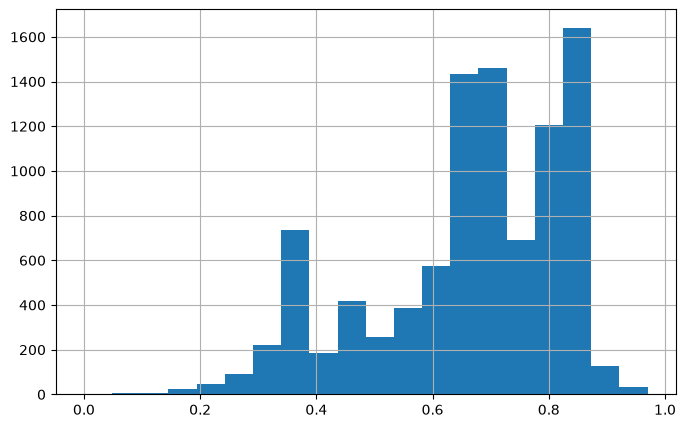

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

resume_df["matched_score"].hist(
    bins=20
)

plt.show()

In [18]:
resume_df.corr(numeric_only=True)

,matched_score
matched_score,1.0


In [19]:
resume_df.shape

(9544, 35)

In [20]:
resume_df.isnull().sum().sort_values(ascending=False)

languages                              8844
proficiency_levels                     8844
address                                8760
issue_dates                            7536
certification_skills                   7536
certification_providers                7536
expiry_dates                           7536
online_links                           7536
extra_curricular_activity_types        6118
extra_curricular_organization_links    6118
extra_curricular_organization_names    6118
role_positions                         6118
career_objective                       4804
age_requirement                        4087
skills_required                        1701
experiencere_requirement               1364
educational_results                      84
educational_institution_name             84
degree_names                             84
major_field_of_studies                   84
locations                                84
related_skils_in_job                     84
positions                       